# Calibrating the probability of establishment via MaxPest

In PnET-Succession, the dispersal of cohorts through seeds goes through a probability check to see if the seeds succeed in creating a new age-chort in a nearby cell where they can disperse.

First is a global check of seeing if the seeds disperse; this is dependant on the dispersal algorithm you're using (`UniversalDispersal` makes the seeds of a given species disperse everywhere on the map; `WardSeedDispersal` computes a probability of success for the dispersal based on the seed dispersal distances defined in the core species parameter file of LANDIS-II). But once the seeds have succeded to disperse in a given cell, there is a second check to see if they will create a new age cohort or not.

In PnET-Succession, this check is done by comparing a random number with a probability of establishment computed dynamically for the occasion. It is computed using :

- The light availability in the cell
- The water availability in the cell
- The MaxPest parameter

As such, the light and water in the cell must be sufficient for a new cohort of this given species to implant. But there's also the MaxPest parameter, which is a number from 0 to 1 which further reduces the probability of establishment. Therefore, MaxPest is a kind of "volume knob" that can lower the probabilities of establishment overall during the entire simulation.

The reason for the existence of MaxPest is that different calibrations can result in different probabilities of implantation for new cohorts. In addition, as there is one opportunity of dispersal/implantation at each timestep per cohort, reducing the timestep results in more opportunities, and thus more implantations, and thus more new cohorts in each cells. MaxPest can therefore make sure that your calibration produces reasonable amounts of age cohorts in the landscape, which is important for two reasons :

- Biological realism (too many cohorts means a more "uneven-aged structure" in your cells and more shade competition, which tends to favor shade-tolerant species)
- Performance (too many cohorts slows down your performance)

The problem is : **How do you know how much cohort you "should" have, on average, in the cells of your landscape ?** How do you know if you should increase or decrease MaxPest to reduce or increase the number of cohorts per cells in your simulation ?

The short answer is : there is no perfect answer here, no criteria that you can use as a definite guide. Here is what Eric Gustafson says in the [calibration guide of PnET-Succession](./ReferencesAndData/Documentation/Gustafson2024PnETUserGuide.pdf) :

> Consider the parameter MaxPest to be a tuning knob to dial all establishment rates up or down. This cannot be done on a single cell and must be done on a landscape before you conduct landscape-scale experiments. I don’t have enough experience to provide concrete guidance. I suggest starting with a MaxPest value of 1.0 (no alteration of Pest) and tune up or down from there if cohort numbers indefinitely increase or decrease, or if mean # of cohorts per cell consistently exceeds about 12. Values of 0.15 or less are not unusual. MaxPest is dependent on the PnET-Succession time step, meaning that you must reset its value when you change the time step. We think it may be as simple as reducing the value in proportion to the change in time step length. For example, if the length of the time step is reduced by half, also reduce the value of MaxPest by half. We are working on a way to modify the code to make MaxPest time-step invariant, but have not yet found a robust method. If establishment seems unresponsive to MaxPest, it may be that you have too many canopy layers, and very little light is reaching the forest floor on most cells.

So as you see, Gustafson recommands a "mean # of cohorts per cell consistently exceeds about 12", or a number of cohorts that doesn't keep increasing or decreasing during the entire simulation. It's a pretty broad criteria, but I think we can trust his experience.

In the following code section, you will find a function that will simulate a small randomized landscape (50x50 cells) with dispersal, with three types of soils distributed in patches : highlands (shallow, drier soils where precipitations tends to runoff); lowlands (fertile, deeper soils); and mucky peat (waterlogged soils). The goal here is to represent a landscape as diversified as possible to try to capture the nuance in species dispersal and implantation resulting from your parameters. The initial age cohorts of the landscape are randomized with an average number of cohorts per cell (with an average of 12), with random species choosen, and with an age attributed to them taken from a Weibull distribution. The function will output the evolution of the average number of cohort per cell in the landscape, as well as the biomass of each species.

You can change MaxPest until you reach a number of cohorts that makes more sense to you. I recommand making sure that it stabilizes after 50 years under 12 cohort per cell on average, but above 5 on average if possible. With the biomass plot, you will see that the more cohorts you allow in your landscape, the more your shade-tolerant species will be favored (and vice-versa).

:::{important} Remember to use the right time step !
Remember that there is 1 opportunity of dispersal/implantation per timestep, and that the smaller your timestep, the more opportunities there will be. You will have to adjust MaxPest as a consequence of your timestep; as such, make sure that you have the right timestep when making these simulations.
:::

:::{tip} Changing your timestep once you have calibrated MaxPest.
Once you have calibrated your timestep, it might be possible to change MaxPest without having to re-calibrate it. Simply change MaxPest as a ratio of the timestep change (e.g. if you're going from a 10 year timestep to a 1 year timestep, divde MaxPest per 10). But it would be better to re-calibrate it here if you can.
:::

:::{tip} Testing different soils and using a historical climate
I recommand you use a non-averaged real historical climate for your study area (derived from Notebook 5) instead of the "mild" climate used in the previous notebook, so as to better represent the harsher/more variable climate conditions in your landscape at this step, since we want to capture the emerging implantation probabilities for your cohorts. In addition, you can easily change the proportion of the three soil types (highlands, lowlands, mucky peat) in the landscape to approximate what will be in your study area. This will make the calibration even more precise.
:::

:::{warning} This code cell will take longer to run
Since we're simulating a landscape here (even if it's a small one), the simulation done here will take more time than the code cells in previous notebooks. It's normal. You can use the `parallel` parameter to boost the speed of the simulation by giving more CPU cores to it (don't go beyond 5; see the Parallel parameter of PnET-Succession in the user guide).
:::

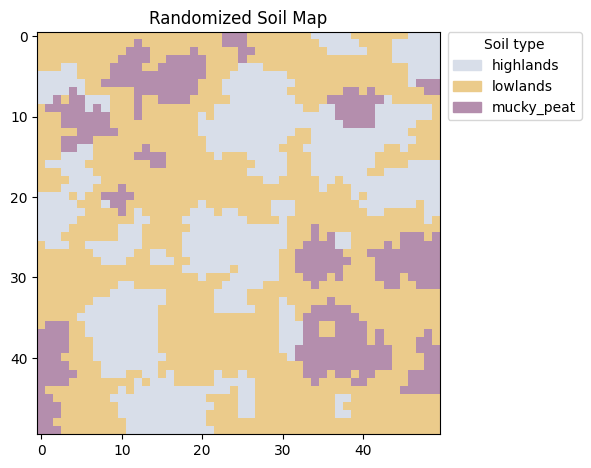

Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/landscapeCalibrationMaxPest/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation has finished properly!


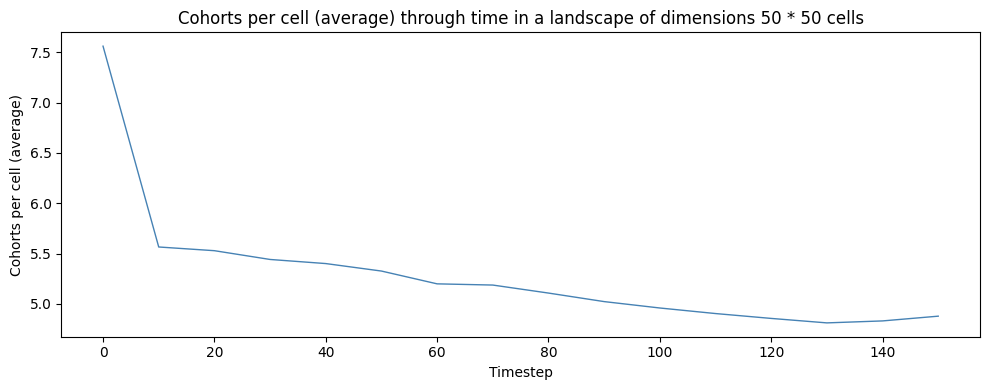

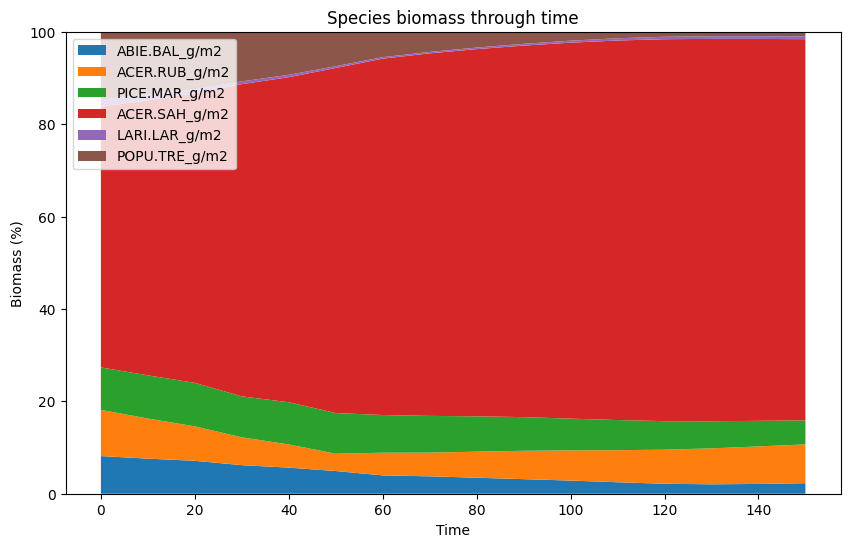

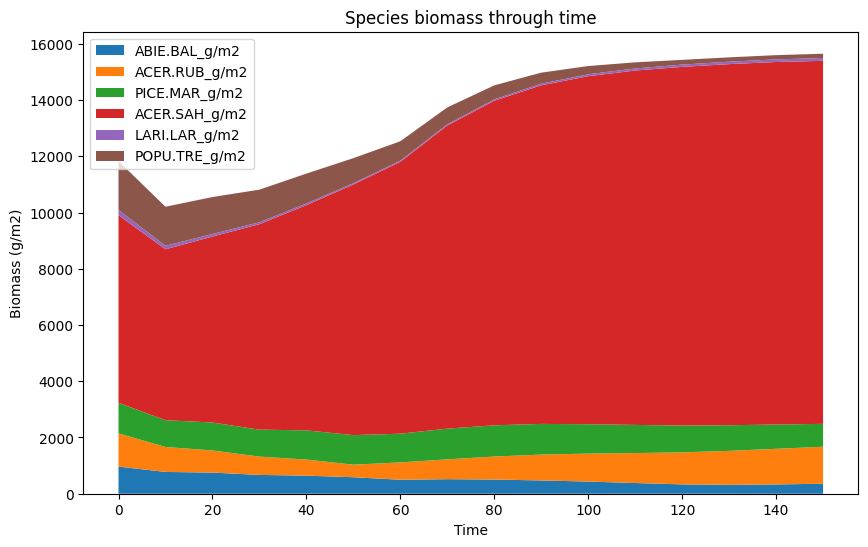

In [23]:
from functionsForCalibration import *

maxPestTestValue = 0.55

calibrationSimulationLandscapeMaxPestManawan(duration = 150, # We're looking at a stabilisation bellow 12 cohorts per cells in 50 years
                                            climate = "realHistorical", # Using historical is better to represent harsher, more complex growing conditions.
                                            soilsProportions = {"highlands":0.3, "lowlands":0.55, "mucky_peat":0.15}, # You can 
                                            timestep = 10,
                                            numberOfCells = 50, # 20 or 50 or more doesn't make a lot of differences; the trend simply becomes smoother with more cells.
                                            maxPest = maxPestTestValue,
                                            dictOfCoreSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/initialCoreSpeciesParameters.json')),
                                            dictOfPnETSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/initialPnETSpeciesParameters.json')),
                                            dictOfPnETGenericParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/InitialGenericParameters.json')),
                                            plotResults = True,
                                            parallel = 5)



# We save a new set of parameters

dictOfCoreSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/initialCoreSpeciesParameters.json'))
dictOfPnETSpeciesParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/initialPnETSpeciesParameters.json'))
dictOfPnETGenericParameters = json.load(open('./SpeciesParametersSets/Calibrated_CompetitionTweaks/InitialGenericParameters.json'))

dictOfPnETGenericParameters["MaxPest"] = str(maxPestTestValue)

if os.path.exists("./SpeciesParametersSets/Final_Parameters"):
    shutil.rmtree("./SpeciesParametersSets/Final_Parameters")
os.mkdir("./SpeciesParametersSets/Final_Parameters")

with open("./SpeciesParametersSets/Final_Parameters/initialCoreSpeciesParameters.json", "w") as f: json.dump(dictOfCoreSpeciesParameters, f)
with open("./SpeciesParametersSets/Final_Parameters/initialPnETSpeciesParameters.json", "w") as f: json.dump(dictOfPnETSpeciesParameters, f)
with open("./SpeciesParametersSets/Final_Parameters/InitialGenericParameters.json", "w") as f: json.dump(dictOfPnETGenericParameters, f)